# Tutorial 5: Perturbation Analysis - Phenotype Switching

In-silico perturbation experiments predict what happens when a TF is knocked down or overexpressed. For the MM_lines melanoma dataset, we'll use this to simulate **phenotype switching** - the transition between melanocytic (MEL) and mesenchymal (MES) states.

## Phenotype Switching in Melanoma

Phenotype switching is a key driver of metastasis and therapy resistance in melanoma.
The SCENIC+ paper showed that knocking down key TFs can induce these transitions:

| Perturbation | Expected Effect |
|--------------|-----------------|  
| **SOX10 KD** | MEL→MES shift (loss of melanocytic identity) |
| **ZEB1 KD** | MES→MEL shift (loss of mesenchymal identity) |

We'll validate this using deepSCENIC's perturbation simulation.

In [1]:
import sys, os

os.environ.pop("PYTHONPATH", None)
os.environ.pop("PYTHONHOME", None)

sys.path = [
    p for p in sys.path
    if "/mnt/modules/easybuild" not in p
]

import typing_extensions
print(typing_extensions.__file__)

sys.path.insert(
    0,
    "/data/groups/vib.ai/stein.aerts/gpartel/software/deepSCENIC-dev/src"
)

/data/groups/vib.ai/stein.aerts/gpartel/software/miniconda3/envs/deepSCENIC/lib/python3.11/site-packages/typing_extensions.py


## Setup

In [2]:
import torch

import deepscenic as ds

print(f"deepSCENIC version: {ds.__version__}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

deepSCENIC version: 0.1.0
Using device: cuda


## Load Model and Data

In [3]:
data_dir = "/data/groups/vib.ai/stein.aerts/gpartel/data/MM_lines_demo/"

# Load trained model and data
model = ds.tl.load_model(data_dir + "checkpoints/deepscenic_model.pt", device=device)
mdata = ds.read(data_dir + "preprocessed_data.h5mu")

print(f"Model: {len(model.tf_names)} TFs")

2026-08-14 16:40:00.926234: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-14 16:40:00.934932: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786718400.944331 2594470 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786718400.947085 2594470 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786718400.954569 2594470 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Model: 1446 TFs


In [4]:
# Define marker genes for tracking phenotype changes
MEL_MARKERS = ["MITF", "DCT", "TYR", "PMEL", "MLANA"]  # Melanocytic markers
MES_MARKERS = ["JUN", "ZEB1", "NFIB"]  # Mesenchymal markers

print(f"MEL markers: {MEL_MARKERS}")
print(f"MES markers: {MES_MARKERS}")

MEL markers: ['MITF', 'DCT', 'TYR', 'PMEL', 'MLANA']
MES markers: ['JUN', 'ZEB1', 'NFIB']


## SOX10 Knockdown: Proof-of-Principle for MEL→MES Transition

SOX10 is a master regulator of the melanocytic lineage. Knocking it down should cause:
1. **Downregulation of MEL markers**
2. **Upregulation of MES markers**: As cells lose melanocytic identity
3. **Shift toward MES state**: Cells should move toward mesenchymal phenotype

Let's simulate this and verify the expected biology.

In [17]:
# Simulate SOX10 knockdown with intermediate results for convergence analysis
perturbed_mtxs, logFC_trace = ds.tl.simulate_perturbation(
    model,
    mdata,
    tf_name="SOX10",
    level=0,  # Complete knockdown
    n_iter=3,
    clip_percentile=99.99,
    return_intermediate=True,  # Get logFC at each iteration
)

print(f"Simulated SOX10 knockdown across {logFC_trace[3].shape[0]} cells")
print(f"Tracking effects on {logFC_trace[3].shape[1]} genes over 3 iterations")

Simulating perturbation:   0%|          | 0/4 [00:00<?, ?it/s]

Simulated SOX10 knockdown across 936 cells
Tracking effects on 12109 genes over 3 iterations


### Perturbation effect in PCA space

PCA is fitted on the original RNA profiles, and the perturbed profiles are projected into that same space. Each arrow connects a cell's original position to its predicted position after SOX10 knockdown.

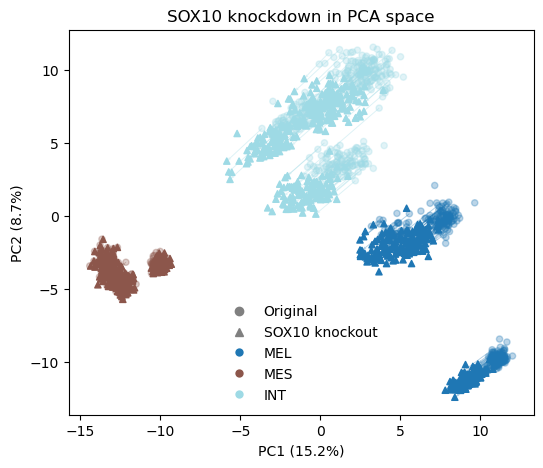

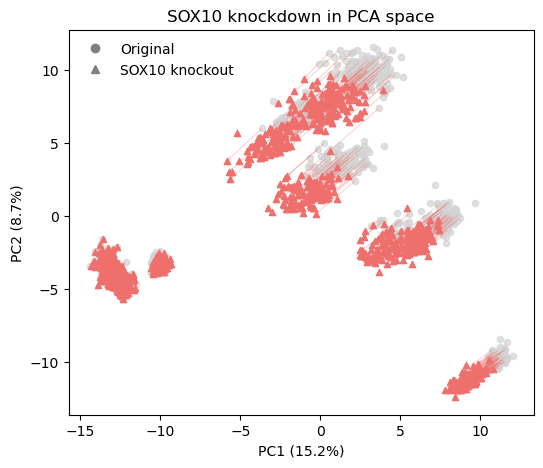

In [19]:
from scipy.sparse import issparse

original_mtx = mdata.mod["rna"].X
original_mtx = original_mtx.toarray() if issparse(original_mtx) else original_mtx

ds.pl.perturbation_pca(
    original_mtx,
    perturbed_mtxs[3],
    obs=mdata.obs,
    color="cell_state",
    original_label="Original",
    perturbed_label="SOX10 knockout",    
    max_arrows=300,
    original_alpha=0.3,
    perturbed_alpha=1.0,
    title="SOX10 knockdown in PCA space",
)

ds.pl.perturbation_pca(
    original_mtx,
    perturbed_mtxs[3],
    obs=mdata.obs,
    original_label="Original",
    perturbed_label="SOX10 knockout",    
    max_arrows=300,
    original_alpha=0.7,
    perturbed_alpha=1.0,
    title="SOX10 knockdown in PCA space",
)

## Iteration Convergence: How Effects Propagate

The perturbation simulation runs iteratively to capture indirect effects through TF-TF regulatory cascades. Let's visualize how marker gene expression changes across iterations:

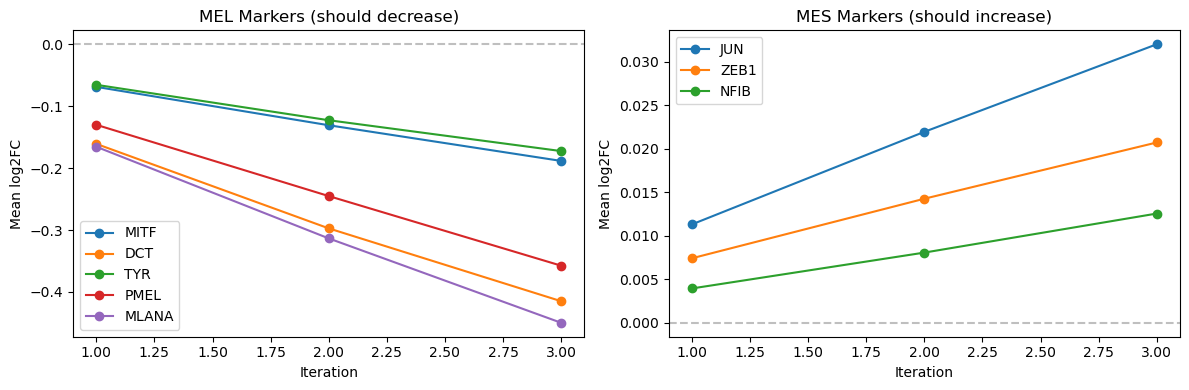

In [20]:
import matplotlib.pyplot as plt

# Get gene indices for markers
gene_names = list(mdata.mod["rna"].var_names)


def get_gene_indices(markers, gene_names):
    """Get indices of marker genes that exist in the dataset."""
    indices = {}
    for m in markers:
        if m in gene_names:
            indices[m] = gene_names.index(m)
    return indices


mel_idx = get_gene_indices(MEL_MARKERS, gene_names)
mes_idx = get_gene_indices(MES_MARKERS, gene_names)

# Extract mean logFC per iteration for each marker
iterations = sorted(logFC_trace.keys())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# MEL markers
for marker, idx in mel_idx.items():
    logfc_per_iter = [logFC_trace[i][:, idx].mean() for i in iterations]
    axes[0].plot(iterations, logfc_per_iter, "o-", label=marker)
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Mean log2FC")
axes[0].set_title("MEL Markers (should decrease)")
axes[0].legend()

# MES markers
for marker, idx in mes_idx.items():
    logfc_per_iter = [logFC_trace[i][:, idx].mean() for i in iterations]
    axes[1].plot(iterations, logfc_per_iter, "o-", label=marker)
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Mean log2FC")
axes[1].set_title("MES Markers (should increase)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Visualize Perturbation Effects

### Waterfall Plot

The waterfall plot shows the top up- and down-regulated genes ranked by effect size:

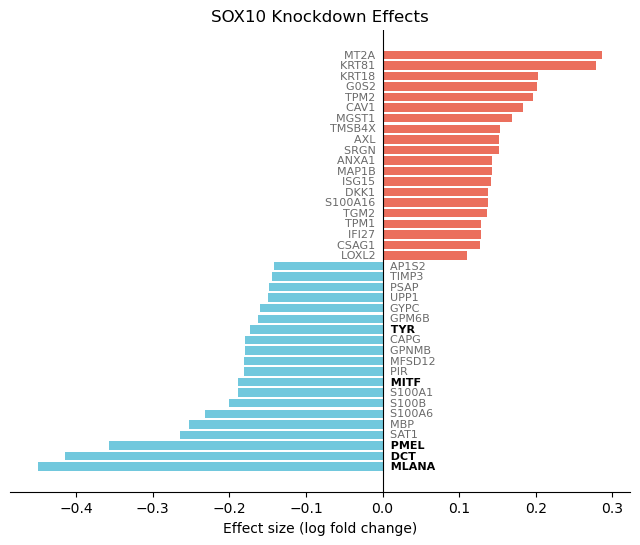

In [22]:
# Process results for plotting
results = ds.tl.process_perturbation_results(logFC_trace[3], mdata, tf_name="SOX10")

# Waterfall plot shows top affected genes ranked by effect size
ds.pl.waterfall_perturbation(results, highlight_genes=MEL_MARKERS + MES_MARKERS, title="SOX10 Knockdown Effects")

## Multi-TF Perturbation

Simulate perturbation of multiple TFs simultaneously:

In [24]:
# Simulate combined knockdown of two TFs
perturbed_multi, logFC_multi = ds.tl.simulate_perturbation(
    model,
    mdata,
    tf_name=["SOX10", "MITF"],
    level=[0, 0],  # Both knocked down
)

results_multi = ds.tl.process_perturbation_results(logFC_multi, mdata, tf_name=["SOX10", "MITF"])
results_multi.sort_values('abs_log2fc', ascending=False).head()

Simulating perturbation:   0%|          | 0/4 [00:00<?, ?it/s]

,gene,tf,log2fc,abs_log2fc
8339,PMEL,SOX10+MITF,-2.496479,2.496479
7094,MT2A,SOX10+MITF,2.406776,2.406776
6917,MLANA,SOX10+MITF,-2.214838,2.214838
3841,DCT,SOX10+MITF,-1.590833,1.590833
6221,KRT81,SOX10+MITF,1.590155,1.590155


## Next Steps

Now that you've analyzed perturbation effects:

- Explore advanced genomic visualizations: {doc}`06_advanced_visualization`